# NuAncestor Telescope Visibility

This notebook compares telescope visibility results obtained from three FreeFlyer simulations. Circular orbits are considered with inclinations 0°, 20°, and 40°.

For each orbit, the night contact windows, elevation tracking speed, and azimuthal tracking speed are compared. The notebook also calculates the mean night contacts/day, equivalent interval between contacts, tracking-speed range, per-telescope visibility statistics, percentage visibility change relative to the i=0° orbit, and invalid night analysis.

Different semi-major axes can be analysed at the same time.

Version 07/2026 by Pedro de S. C. Leonardo

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path
from IPython.display import display

In [2]:
# Main folder containing the three simulation folders
BASE = Path("All_Results/InclinationCompared/365_days")
#BASE = Path("All_Results/InclinationCompared/30_days")

# Settings to change !!
SEMI_MAJOR_AXES = [23200, 28750]  # km
INCLINATIONS = [0, 20, 40]

DAYS = 365  # 365 or 30
SAVE_FIGURES = False
SHOW_REQUIREMENTS = False
MAX_ELEVATION_SPEED = 15
MAX_AZIMUTHAL_SPEED = 600

In [3]:
stations = ["Chile", "La Palma", "Hawaii", "SALT", "DAG"]
colors = ["r", "blueviolet", "cyan", "orange", "lime"]

# Orbits are ordered from top to bottom in the plots
cases = [
    {"name": f"a = {semi_major_axis:,} km, i = {inclination}°",
     "semi_major_axis": semi_major_axis,
     "inclination": inclination,
     "folder": f"Results_a{semi_major_axis}_i{inclination}"}
    for semi_major_axis in SEMI_MAJOR_AXES
    for inclination in INCLINATIONS]


# Read one FreeFlyer results file
def read_result(folder, filename):
    path = BASE / folder / filename
    return pd.read_csv(path, skiprows=3, sep=r"\s+").to_numpy(dtype=float)

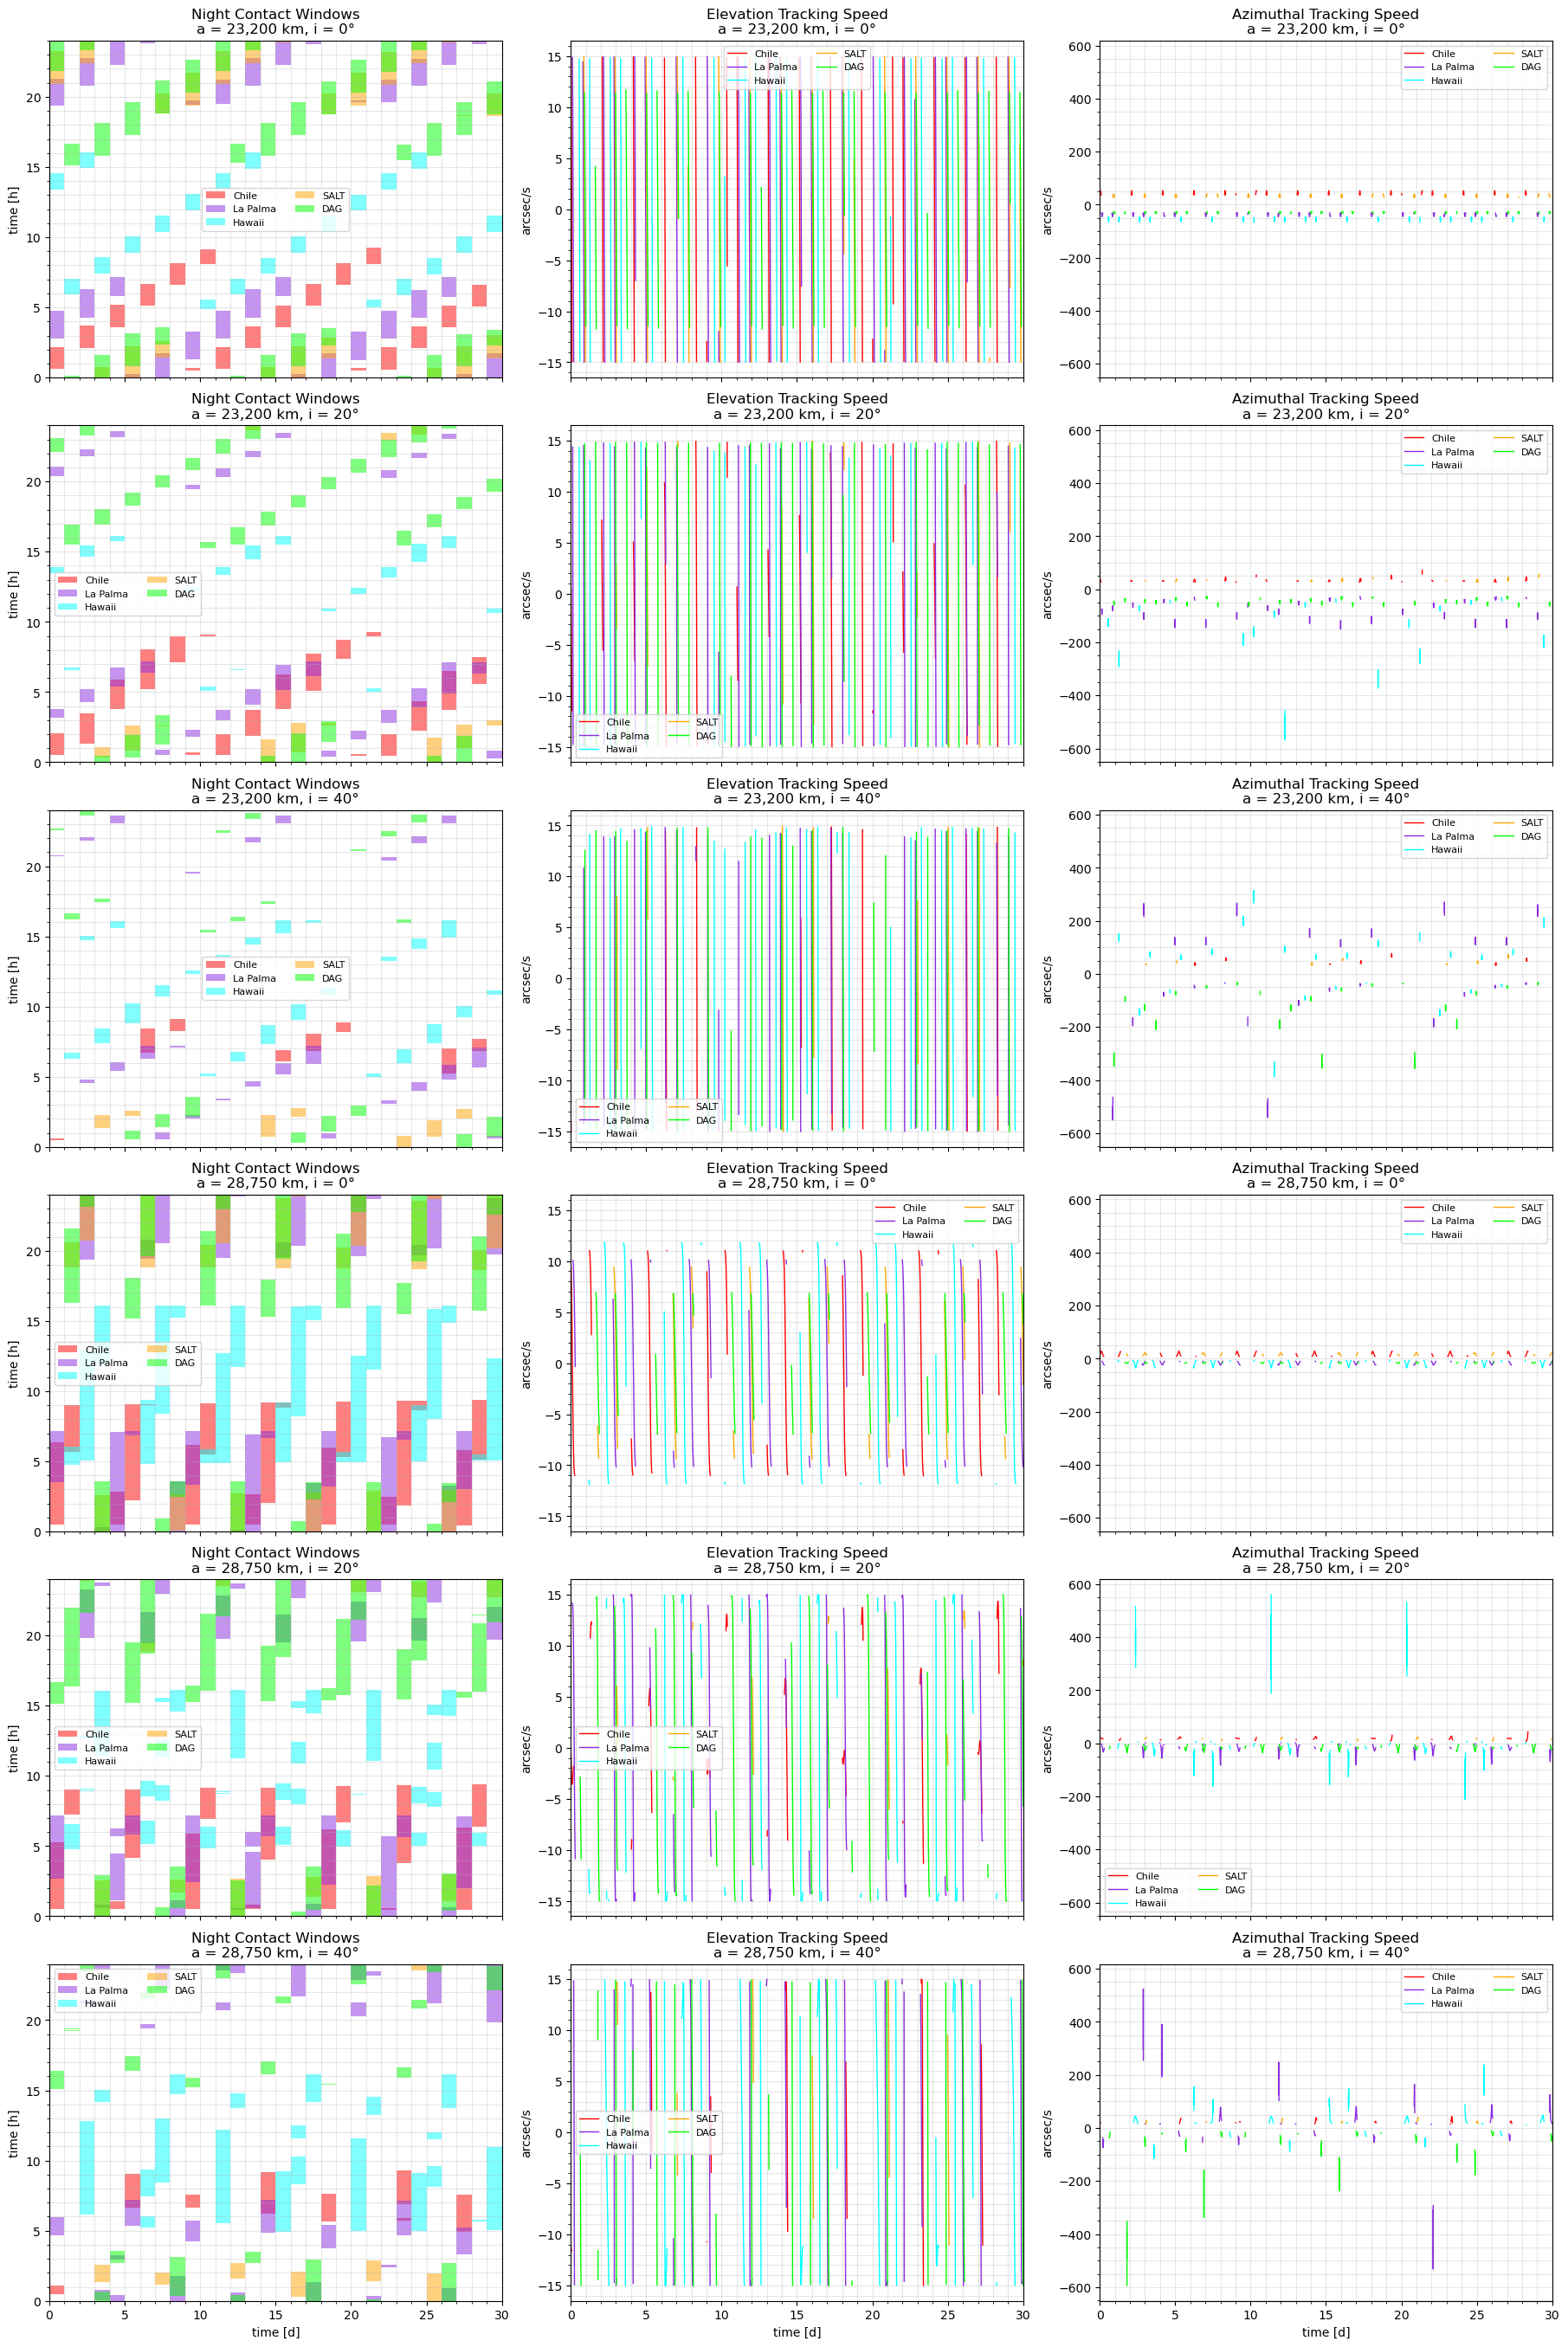

In [4]:
# Days to plot
START_DAY = 0
END_DAY = 30


def plot_contact_windows(ax, folder, title):
    data = read_result(folder, "InContact.txt")
    data = data[
        (data[:, 0] >= START_DAY) &
        (data[:, 0] <= END_DAY)]

    time = data[:, 0]
    day = np.floor(time) + 0.5
    hour = (time - np.floor(time)) * 24
    dt_hours = np.median(np.diff(time)) * 24

    for i, station in enumerate(stations):
        visible = data[:, i + 1] == 1
        ax.bar(
            day[visible],
            np.full(visible.sum(), dt_hours),
            width=1,
            bottom=hour[visible],
            color=colors[i],
            alpha=0.5,
            label=station)

    ax.set_title(title)
    ax.set_ylabel("time [h]")
    ax.set_xlim(START_DAY, END_DAY)
    ax.set_ylim(0, 24)
    ax.minorticks_on()
    ax.grid(which="both", alpha=0.3)
    ax.legend(fontsize=8, ncol=2)


def plot_speed(ax, folder, filename, title, requirement=None):
    data = read_result(folder, filename)
    data = data[
        (data[:, 0] >= START_DAY) &
        (data[:, 0] <= END_DAY)]

    time = data[:, 0]
    values = data[:, 1:].copy()

    # Ignore zeros outside contact windows
    values[values == 0] = np.nan

    for i, station in enumerate(stations):
        ax.plot(
            time,
            values[:, i],
            color=colors[i],
            linewidth=1,
            label=station)

    # Optional telescope requirement
    if SHOW_REQUIREMENTS and requirement is not None:
        ax.axhline(
            requirement,
            color="black",
            linestyle="--",
            linewidth=1.2,
            label=f"Requirement: {requirement:g} arcsec/s")

    ax.set_title(title)
    ax.set_ylabel("arcsec/s")
    ax.set_xlim(START_DAY, END_DAY)
    ax.minorticks_on()
    ax.grid(which="both", alpha=0.3)
    ax.legend(fontsize=8, ncol=2)


fig, axes = plt.subplots(
    len(cases), 3,
    figsize=(18, 4.5 * len(cases)),
    sharex="col",
    sharey="col",
    constrained_layout=True)

for row, case in enumerate(cases):
    subtitle = case["name"]

    plot_contact_windows(
        axes[row, 0],
        case["folder"],
        f"Night Contact Windows\n{subtitle}")

    plot_speed(
        axes[row, 1],
        case["folder"],
        "Elevation Speed.txt",
        f"Elevation Tracking Speed\n{subtitle}",
        requirement=MAX_ELEVATION_SPEED)

    plot_speed(
        axes[row, 2],
        case["folder"],
        "Azimuthal Speed.txt",
        f"Azimuthal Tracking Speed\n{subtitle}",
        requirement=MAX_AZIMUTHAL_SPEED)

for ax in axes[-1, :]:
    ax.set_xlabel("time [d]")

# Change SAVE_FIGURES to True to save the figure
if SAVE_FIGURES:
    output = BASE / "comparison_plots"
    output.mkdir(exist_ok=True)

    fig.savefig(
        output / f"inclination_comparison_all_orbits_days{START_DAY}-{END_DAY}.png",
        dpi=300,
        bbox_inches="tight")

plt.show()

In [5]:
MU_EARTH = 398600.4418  # Earth's gravitational parameter [km^3/s^2]


def contact_statistics(folder):
    data = read_result(folder, "InContact.txt")
    data = data[(data[:, 0] >= 0) & (data[:, 0] <= DAYS)]

    time = data[:, 0]
    in_contact = data[:, 1:] == 1

    previous = np.vstack((
        np.zeros((1, in_contact.shape[1]), dtype=bool),
        in_contact[:-1]))
    contact_starts = in_contact & ~previous

    duration_days = time[-1] - time[0]
    contacts_per_day = contact_starts.sum(axis=0) / duration_days
    mean_contacts_per_day = contacts_per_day.mean()

    mean_interval_hours = (
        24 / mean_contacts_per_day
        if mean_contacts_per_day > 0 else np.nan)

    return mean_contacts_per_day, mean_interval_hours


def tracking_speed_range(folder):
    data = read_result(folder, "Tracking Speed.txt")
    data = data[(data[:, 0] >= 0) & (data[:, 0] <= DAYS)]

    maxima = []

    for values in data[:, 1:].T:
        values = np.abs(values[np.isfinite(values) & (values != 0)])

        if values.size:
            maxima.append(values.max())

    return (
        (min(maxima), max(maxima))
        if maxima else (np.nan, np.nan))


def fmt(value, decimals=2):
    return f"{value:.{decimals}f}".rstrip("0").rstrip(".")


columns = {}

for case in cases:
    semi_major_axis = case["semi_major_axis"]
    period_hours = 2 * np.pi * np.sqrt(semi_major_axis**3 / MU_EARTH) / 3600
    contacts_per_day, interval_hours = contact_statistics(case["folder"])
    speed_min, speed_max = tracking_speed_range(case["folder"])

    columns[case["name"]] = [
        f"{semi_major_axis:,} km",
        f"{period_hours:.3f} h",
        f"{case['inclination']}°",
        f"{contacts_per_day:.3f}",
        f"{interval_hours:.2f} h",
        f"{fmt(speed_min)} – {fmt(speed_max)} arcsec/s"]


summary = pd.DataFrame(columns, index=[
    "Semi-major axis",
    "Orbit period",
    "Orbit inclination",
    "Mean night contacts/day per telescope",
    "Equivalent mean interval between night contacts",
    "Max. tracking speed for different latitudes"])

summary.index.name = "Orbit"

table_styles = [
    {"selector": "th", "props": [
        ("text-align", "center"),
        ("font-weight", "bold"),
        ("border", "1px solid black")]},
    {"selector": "td", "props": [
        ("text-align", "center"),
        ("border", "1px solid black")]}]

display(summary.style.set_table_styles(table_styles))

,"a = 23,200 km, i = 0°","a = 23,200 km, i = 20°","a = 23,200 km, i = 40°","a = 28,750 km, i = 0°","a = 28,750 km, i = 20°","a = 28,750 km, i = 40°"
Orbit,,,,,,
Semi-major axis,"23,200 km","23,200 km","23,200 km","28,750 km","28,750 km","28,750 km"
Orbit period,9.769 h,9.769 h,9.769 h,13.476 h,13.476 h,13.476 h
Orbit inclination,0°,20°,40°,0°,20°,40°
Mean night contacts/day per telescope,0.718,0.603,0.533,0.548,0.598,0.483
Equivalent mean interval between night contacts,33.41 h,39.82 h,45.06 h,43.80 h,40.11 h,49.72 h
Max. tracking speed for different latitudes,27.01 – 29.25 arcsec/s,30.4 – 31.71 arcsec/s,35.62 – 36.92 arcsec/s,13.88 – 14.71 arcsec/s,16.32 – 17.18 arcsec/s,21.63 – 22.75 arcsec/s


In [6]:
# Telescopes to include in the statistics
SELECTED_TELESCOPES = ["Chile", "La Palma", "Hawaii", "SALT", "DAG"]


def contact_intervals(time, visible):
    """Return the start and end time of every continuous contact window."""
    dt = np.median(np.diff(time))
    end_of_data = time[-1] + dt

    # Detect transitions into and out of contact
    changes = np.diff(visible.astype(int))
    starts = list(time[1:][changes == 1])
    ends = list(time[1:][changes == -1])

    # Include contacts active at the start or end
    if visible[0]:
        starts.insert(0, time[0])
    if visible[-1]:
        ends.append(end_of_data)

    return np.array(starts), np.array(ends), end_of_data


def visibility_statistics(time, visible):
    starts, ends, end_of_data = contact_intervals(time, visible)
    durations = (ends - starts) * 24

    if durations.size:
        median_duration = np.median(durations)
        maximum_duration = np.max(durations)
        total_contact = np.sum(durations)
    else:
        median_duration = np.nan
        maximum_duration = np.nan
        total_contact = 0.0

    # Include gaps at the beginning and end
    if starts.size:
        gaps = [starts[0] - time[0]]
        gaps.extend(starts[1:] - ends[:-1])
        gaps.append(end_of_data - ends[-1])
        maximum_gap = np.max(gaps) * 24
    else:
        maximum_gap = (end_of_data - time[0]) * 24

    return {
        "total_contact_h": total_contact,
        "median_duration_h": median_duration,
        "maximum_duration_h": maximum_duration,
        "maximum_gap_h": maximum_gap}


case_by_orbit = {
    (case["semi_major_axis"], case["inclination"]): case
    for case in cases}

rows = []

for semi_major_axis in SEMI_MAJOR_AXES:
    baseline_case = case_by_orbit[(semi_major_axis, 0)]
    baseline = read_result(baseline_case["folder"], "InContact.txt")
    baseline = baseline[
        (baseline[:, 0] >= 0) & (baseline[:, 0] <= DAYS)]

    for inclination in INCLINATIONS:
        if inclination == 0:
            continue

        compared_case = case_by_orbit[(semi_major_axis, inclination)]
        compared = read_result(compared_case["folder"], "InContact.txt")
        compared = compared[
            (compared[:, 0] >= 0) & (compared[:, 0] <= DAYS)]

        if baseline.shape != compared.shape or not np.allclose(
            baseline[:, 0], compared[:, 0], rtol=0, atol=1e-10):
            raise ValueError(
                f"Time grids do not match for a = {semi_major_axis} km, "
                f"i = 0° and i = {inclination}°.")

        time = baseline[:, 0]

        for station in SELECTED_TELESCOPES:
            i = stations.index(station)

            baseline_visible = baseline[:, i + 1] == 1
            compared_visible = compared[:, i + 1] == 1

            baseline_stats = visibility_statistics(time, baseline_visible)
            compared_stats = visibility_statistics(time, compared_visible)

            difference_hours = (
                compared_stats["total_contact_h"]
                - baseline_stats["total_contact_h"])

            change_percent = (
                100 * difference_hours / baseline_stats["total_contact_h"]
                if baseline_stats["total_contact_h"] > 0 else np.nan)

            rows.append({
                "Semi-major axis [km]": semi_major_axis,
                "Inclination [deg]": inclination,
                "Telescope": station,
                "i = 0 total contact [h]": baseline_stats["total_contact_h"],
                "Compared total contact [h]": compared_stats["total_contact_h"],
                "Difference from i = 0 [h]": difference_hours,
                "Visibility change from i = 0 [%]": change_percent,
                "i = 0 median duration [h]": baseline_stats["median_duration_h"],
                "Compared median duration [h]": compared_stats["median_duration_h"],
                "i = 0 maximum duration [h]": baseline_stats["maximum_duration_h"],
                "Compared maximum duration [h]": compared_stats["maximum_duration_h"],
                "i = 0 maximum gap [h]": baseline_stats["maximum_gap_h"],
                "Compared maximum gap [h]": compared_stats["maximum_gap_h"]})

contact_stats = pd.DataFrame(rows).round(2)
display(contact_stats)

,Semi-major axis [km],Inclination [deg],Telescope,i = 0 total contact [h],Compared total contact [h],Difference from i = 0 [h],Visibility change from i = 0 [%],i = 0 median duration [h],Compared median duration [h],i = 0 maximum duration [h],Compared maximum duration [h],i = 0 maximum gap [h],Compared maximum gap [h]
0,23200,20,Chile,349.62,286.81,-62.81,-17.96,1.55,0.87,1.58,2.80,47.96,49.16
1,23200,20,La Palma,435.30,239.17,-196.13,-45.06,1.97,0.83,2.00,2.56,47.54,148.08
2,23200,20,Hawaii,260.86,257.59,-3.27,-1.25,1.15,0.82,1.17,3.19,48.35,164.78
3,23200,20,SALT,517.64,223.61,-294.03,-56.80,2.33,0.93,2.37,2.40,47.18,212.94
4,23200,20,DAG,495.77,225.50,-270.27,-54.51,2.32,1.07,2.35,2.16,65.52,941.80
5,23200,40,Chile,349.62,124.32,-225.30,-64.44,1.55,0.58,1.58,1.74,47.96,213.62
6,23200,40,La Palma,435.30,114.76,-320.54,-73.64,1.97,0.47,2.00,1.66,47.54,214.48
7,23200,40,Hawaii,260.86,156.02,-104.83,-40.19,1.15,0.54,1.17,1.83,48.35,149.73
8,23200,40,SALT,517.64,104.76,-412.88,-79.76,2.33,0.38,2.37,1.60,47.18,263.19
9,23200,40,DAG,495.77,101.53,-394.23,-79.52,2.32,0.52,2.35,1.43,65.52,1109.03


#### Contact statistics:

- i = 0 total contact [h]: Total usable contact time for the baseline orbit.
- Compared total contact [h]: Total usable contact time for the inclined orbit.
- Difference from i = 0 [h]: Absolute contact-time change relative to i=0. Positive values indicate more contact and negative values indicate less.
- Visibility change from i = 0 [%]: Percentage change in total contact relative to the baseline orbit.
- Median duration [h]: Median duration of an individual continuous contact window.
- Maximum duration [h]: Duration of the longest continuous contact window.
- Maximum gap [h]: Longest continuous period without contact, including gaps at the beginning and end of the analysis.

In [7]:
orbit_rows = []

for case in cases:
    data = read_result(case["folder"], "InContact.txt")
    data = data[
        (data[:, 0] >= 0) & (data[:, 0] <= DAYS)]

    time = data[:, 0]

    for station in SELECTED_TELESCOPES:
        i = stations.index(station)
        visible = data[:, i + 1] == 1

        stats = visibility_statistics(time, visible)

        orbit_rows.append({
            "Semi-major axis [km]": case["semi_major_axis"],
            "Inclination [deg]": case["inclination"],
            "Telescope": station,
            "Total contact [h]": stats["total_contact_h"],
            "Median duration [h]": stats["median_duration_h"],
            "Maximum duration [h]": stats["maximum_duration_h"],
            "Maximum gap [h]": stats["maximum_gap_h"]})


orbit_stats = pd.DataFrame(orbit_rows)

summary_stats = (
    orbit_stats
    .groupby(["Semi-major axis [km]", "Inclination [deg]"], as_index=False)
    .mean(numeric_only=True)
    .rename(columns={
        "Total contact [h]": "Mean total contact [h]",
        "Median duration [h]": "Mean median duration [h]",
        "Maximum duration [h]": "Mean maximum duration [h]",
        "Maximum gap [h]": "Mean maximum gap [h]"})
    .round(2))

display(summary_stats)

,Semi-major axis [km],Inclination [deg],Mean total contact [h],Mean median duration [h],Mean maximum duration [h],Mean maximum gap [h]
0,23200,0,411.84,1.86,1.89,51.31
1,23200,20,246.54,0.90,2.62,303.35
2,23200,40,120.28,0.50,1.65,390.01
3,28750,0,817.51,4.42,6.89,88.39
4,28750,20,586.01,2.39,6.73,189.67
5,28750,40,296.61,1.30,4.63,327.24


In [8]:
def visibility_label(percent, hours):
    if pd.isna(percent):
        return "Undefined"
    if percent > 0:
        return f"+{percent:.2f}% (+{hours:.2f} h)"
    if percent < 0:
        return f"-{abs(percent):.2f}% (-{abs(hours):.2f} h)"
    return "No change"


visibility_percent = (
    contact_stats
    .pivot(
        index="Telescope",
        columns=["Semi-major axis [km]", "Inclination [deg]"],
        values="Visibility change from i = 0 [%]")
    .reindex(SELECTED_TELESCOPES))

visibility_hours = (
    contact_stats
    .pivot(
        index="Telescope",
        columns=["Semi-major axis [km]", "Inclination [deg]"],
        values="Difference from i = 0 [h]")
    .reindex(SELECTED_TELESCOPES))

visibility_comparison = pd.DataFrame(index=SELECTED_TELESCOPES)

for semi_major_axis, inclination in visibility_percent.columns:
    column_name = (
        f"a = {semi_major_axis:,} km, "
        f"i = {inclination}° compared with i = 0°")

    visibility_comparison[column_name] = [
        visibility_label(percent, hours)
        for percent, hours in zip(
            visibility_percent[(semi_major_axis, inclination)],
            visibility_hours[(semi_major_axis, inclination)])]

visibility_comparison.index.name = "Telescope"
display(visibility_comparison)

,"a = 23,200 km, i = 20° compared with i = 0°","a = 23,200 km, i = 40° compared with i = 0°","a = 28,750 km, i = 20° compared with i = 0°","a = 28,750 km, i = 40° compared with i = 0°"
Telescope,,,,
Chile,-17.96% (-62.81 h),-64.44% (-225.30 h),-30.31% (-273.14 h),-60.64% (-546.46 h)
La Palma,-45.06% (-196.13 h),-73.64% (-320.54 h),-29.12% (-244.38 h),-65.00% (-545.52 h)
Hawaii,-1.25% (-3.27 h),-40.19% (-104.83 h),-34.59% (-327.83 h),-54.96% (-520.90 h)
SALT,-56.80% (-294.03 h),-79.76% (-412.88 h),-30.88% (-246.17 h),-73.38% (-584.98 h)
DAG,-54.51% (-270.27 h),-79.52% (-394.23 h),-10.95% (-65.95 h),-67.54% (-406.65 h)


## Invalid Night Analysis:

In [9]:
# Contact requirement settings
MIN_VALID_CONTACT_H = 0.5  # 30 minutes
MAX_CONSECUTIVE_MISSED_NIGHTS = 1
REQUIREMENT_TELESCOPES = ["Chile", "La Palma", "Hawaii", "SALT", "DAG"]
EXCLUDE_PARTIAL_EDGE_NIGHTS = True # If true, a nighttime interval already underway when the simulation begins,
                                   # or unfinished when it ends, is excluded.
                                   # This prevents a partial night from being incorrectly classified as missed.

# In the return block, comment in or out exactly which nights violate the cadence requirement


def infer_simulation_end(time):
    """Infer the simulation end time from the output samples."""
    if len(time) < 2:
        raise ValueError("At least two output time samples are required.")

    time_steps = np.diff(time)

    if not np.all(time_steps > 0):
        raise ValueError("Output times must be strictly increasing.")

    dt = np.median(time_steps)

    return time[-1] + dt


def get_boolean_intervals(time, state, simulation_end):
    """Return the start and end times of each continuous True interval."""
    state = np.asarray(state, dtype=bool)

    if len(time) != len(state):
        raise ValueError("Time and Boolean state arrays must have equal lengths.")

    padded = np.r_[False, state, False]
    start_indices = np.where(np.diff(padded.astype(int)) == 1)[0]
    end_indices = np.where(np.diff(padded.astype(int)) == -1)[0]

    interval_starts = time[start_indices]
    interval_ends = np.array([time[index] if index < len(time) else simulation_end
                              for index in end_indices])

    return interval_starts, interval_ends


def get_night_intervals(time, is_night, simulation_end):
    """
    Return the continuous nighttime intervals for one telescope.

    When EXCLUDE_PARTIAL_EDGE_NIGHTS is True, a night already underway
    at the start of the simulation or unfinished at the end is excluded.
    """
    night_starts, night_ends = get_boolean_intervals(
        time, is_night, simulation_end)

    keep = np.ones(len(night_starts), dtype=bool)

    if EXCLUDE_PARTIAL_EDGE_NIGHTS and len(night_starts) > 0:
        if is_night[0]:
            keep[0] = False
        if is_night[-1]:
            keep[-1] = False

    return night_starts[keep], night_ends[keep]


def get_missed_night_runs(night_has_valid_contact):
    """Return inclusive ranges of consecutive nights without valid contact."""
    runs = []
    run_start = None

    for night_index, has_contact in enumerate(night_has_valid_contact):
        if not has_contact and run_start is None:
            run_start = night_index
        elif has_contact and run_start is not None:
            runs.append((run_start, night_index - 1))
            run_start = None

    if run_start is not None:
        runs.append((run_start, len(night_has_valid_contact) - 1))

    return runs


def evaluate_telescope_requirements(time, visible, is_night, simulation_end):
    """
    Evaluate both requirements for one telescope.

    Requirement 1:
        A continuous contact within a nighttime interval must last at
        least 30 minutes.

    Requirement 2:
        At most one consecutive night may have no valid contact.
        In longer streaks, nights from the second missed night onward
        are counted as cadence-invalid.
    """
    night_starts, night_ends = get_night_intervals(
        time, is_night, simulation_end)

    if len(night_starts) == 0:
        raise ValueError("No complete nighttime intervals were found.")

    contact_starts, contact_ends = get_boolean_intervals(
        time, visible, simulation_end)

    night_has_valid_contact = np.zeros(len(night_starts), dtype=bool)
    valid_contact_count = 0

    for night_index, (night_start, night_end) in enumerate(
        zip(night_starts, night_ends)):

        overlap_starts = np.maximum(contact_starts, night_start)
        overlap_ends = np.minimum(contact_ends, night_end)
        overlap_durations_h = np.maximum(0, overlap_ends - overlap_starts) * 24
        valid_contacts = overlap_durations_h >= MIN_VALID_CONTACT_H - 1e-9

        night_has_valid_contact[night_index] = np.any(valid_contacts)
        valid_contact_count += int(valid_contacts.sum())

    missed_runs = get_missed_night_runs(night_has_valid_contact)

    longest_missed_streak = max(
        (end - start + 1 for start, end in missed_runs), default=0)

    invalid_nights = sum(
        max(0, end - start + 1 - MAX_CONSECUTIVE_MISSED_NIGHTS)
        for start, end in missed_runs)

    violating_streaks = [
        f"Nights {start + 1}–{end + 1}"
        for start, end in missed_runs
        if end - start + 1 > MAX_CONSECUTIVE_MISSED_NIGHTS]

    return {
        "Analysed nights": len(night_starts),
        "Valid contacts [≥30 min]": valid_contact_count,
        "Nights with valid contact": int(night_has_valid_contact.sum()),
        "Missed nights": int((~night_has_valid_contact).sum()),
        "Invalid nights": invalid_nights,
        "Longest missed streak [nights]": longest_missed_streak,
        "Cadence requirement satisfied": "Yes" if invalid_nights == 0 else "No",
        # "Violating streaks": ", ".join(violating_streaks)
        # if violating_streaks else "None"
    }


def create_inclination_requirement_table(case):
    """Create one telescope requirement table for one orbit."""
    rows = []

    folder = case["folder"]
    contact_data = read_result(folder, "InContact.txt")
    night_data = read_result(folder, "IsNight.txt")

    # Limit both files to the selected simulation duration
    contact_data = contact_data[
        (contact_data[:, 0] >= 0) & (contact_data[:, 0] < DAYS)]
    night_data = night_data[
        (night_data[:, 0] >= 0) & (night_data[:, 0] < DAYS)]

    contact_time = contact_data[:, 0]
    night_time = night_data[:, 0]

    if len(contact_time) != len(night_time):
        raise ValueError(
            f"InContact.txt and IsNight.txt have different lengths in {folder}.")

    if not np.allclose(contact_time, night_time, rtol=0, atol=1e-10):
        raise ValueError(
            f"InContact.txt and IsNight.txt use different time samples in {folder}.")

    simulation_end = min(DAYS, infer_simulation_end(contact_time))

    for telescope in REQUIREMENT_TELESCOPES:
        column = stations.index(telescope) + 1
        visible = contact_data[:, column] >= 0.5
        is_night = night_data[:, column] >= 0.5

        result = evaluate_telescope_requirements(
            contact_time, visible, is_night, simulation_end)

        rows.append({"Semi-major axis [km]": case["semi_major_axis"],
                     "Inclination [deg]": case["inclination"],
                     "Telescope": telescope,
                     **result})

    return pd.DataFrame(rows)


# Display one table for each orbit
inclination_tables = {}

for case in cases:
    orbit_name = case["name"]
    inclination_table = create_inclination_requirement_table(case)
    inclination_tables[orbit_name] = inclination_table

    print(f"\n{orbit_name}")
    display(inclination_table.style.hide(axis="index"))


a = 23,200 km, i = 0°


Semi-major axis [km],Inclination [deg],Telescope,Analysed nights,Valid contacts [≥30 min],Nights with valid contact,Missed nights,Invalid nights,Longest missed streak [nights],Cadence requirement satisfied
23200,0,Chile,365,237,237,128,0,1,Yes
23200,0,La Palma,364,239,239,125,0,1,Yes
23200,0,Hawaii,365,229,229,136,0,1,Yes
23200,0,SALT,364,246,246,118,0,1,Yes
23200,0,DAG,364,241,241,123,7,2,No



a = 23,200 km, i = 20°


Semi-major axis [km],Inclination [deg],Telescope,Analysed nights,Valid contacts [≥30 min],Nights with valid contact,Missed nights,Invalid nights,Longest missed streak [nights],Cadence requirement satisfied
23200,20,Chile,365,168,168,197,44,7,No
23200,20,La Palma,364,170,170,194,64,6,No
23200,20,Hawaii,365,144,144,221,91,10,No
23200,20,SALT,364,187,187,177,78,8,No
23200,20,DAG,364,174,174,190,103,38,No



a = 23,200 km, i = 40°


...

Semi-major axis [km],Inclination [deg],Telescope,Analysed nights,Valid contacts [≥30 min],Nights with valid contact,Missed nights,Invalid nights,Longest missed streak [nights],Cadence requirement satisfied
28750,0,Chile,365,198,198,167,86,3,No
28750,0,La Palma,364,192,192,172,91,3,No
28750,0,Hawaii,365,203,203,162,81,3,No
28750,0,SALT,364,193,193,171,90,3,No
28750,0,DAG,364,164,164,200,119,3,No



a = 28,750 km, i = 20°


Semi-major axis [km],Inclination [deg],Telescope,Analysed nights,Valid contacts [≥30 min],Nights with valid contact,Missed nights,Invalid nights,Longest missed streak [nights],Cadence requirement satisfied
28750,20,Chile,365,195,174,191,110,3,No
28750,20,La Palma,364,175,164,200,119,4,No
28750,20,Hawaii,365,212,173,192,102,3,No
28750,20,SALT,364,162,158,206,125,4,No
28750,20,DAG,364,142,142,222,152,31,No



a = 28,750 km, i = 40°


Semi-major axis [km],Inclination [deg],Telescope,Analysed nights,Valid contacts [≥30 min],Nights with valid contact,Missed nights,Invalid nights,Longest missed streak [nights],Cadence requirement satisfied
28750,40,Chile,365,151,142,223,143,8,No
28750,40,La Palma,364,140,130,234,154,8,No
28750,40,Hawaii,365,168,153,212,129,8,No
28750,40,SALT,364,115,115,249,174,8,No
28750,40,DAG,364,111,111,253,170,48,No


In [10]:
# Summary table: invalid nights per telescope for each orbit
summary_rows = []

for case in cases:
    orbit_name = case["name"]
    inclination_table = inclination_tables[orbit_name]

    row = {"Semi-major axis [km]": case["semi_major_axis"],
           "Inclination [deg]": case["inclination"]}

    for telescope in REQUIREMENT_TELESCOPES:
        telescope_data = inclination_table[
            inclination_table["Telescope"] == telescope]

        row[telescope] = int(telescope_data["Invalid nights"].sum())

    row["Total invalid nights"] = sum(
        row[telescope] for telescope in REQUIREMENT_TELESCOPES)

    summary_rows.append(row)

invalid_nights_summary = pd.DataFrame(summary_rows)

display(invalid_nights_summary.style.hide(axis="index"))

Semi-major axis [km],Inclination [deg],Chile,La Palma,Hawaii,SALT,DAG,Total invalid nights
23200,0,0,0,0,0,7,7
23200,20,44,64,91,78,103,380
23200,40,188,209,171,186,184,938
28750,0,86,91,81,90,119,467
28750,20,110,119,102,125,152,608
28750,40,143,154,129,174,170,770


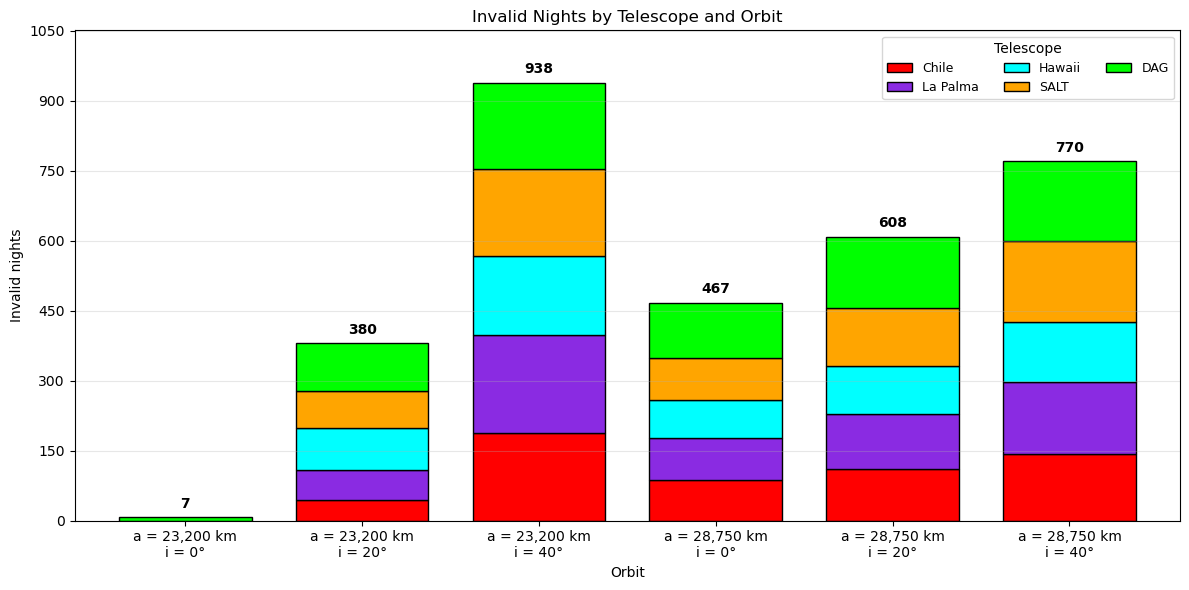

In [11]:
# Plot invalid nights per telescope for each orbit
from matplotlib.ticker import MaxNLocator

summary_rows = []

for case in cases:
    orbit_name = case["name"]
    inclination_table = inclination_tables[orbit_name]

    row = {"Orbit": f"a = {case['semi_major_axis']:,} km\ni = {case['inclination']}°"}

    for telescope in REQUIREMENT_TELESCOPES:
        telescope_data = inclination_table[
            inclination_table["Telescope"] == telescope]

        row[telescope] = int(telescope_data["Invalid nights"].sum())

    summary_rows.append(row)

invalid_nights_summary = pd.DataFrame(summary_rows).set_index("Orbit")
plot_colors = [
    colors[stations.index(telescope)]
    for telescope in REQUIREMENT_TELESCOPES]

ax = invalid_nights_summary.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=plot_colors,
    width=0.75,
    edgecolor="black")

totals = invalid_nights_summary.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        i, total + max(0.2, totals.max() * 0.015),
        f"{int(total)}",
        ha="center",
        va="bottom",
        fontweight="bold")

ax.set_title(
    "Invalid Nights by Telescope and Orbit")
ax.set_xlabel("Orbit")
ax.set_ylabel("Invalid nights")
ax.set_ylim(
    0, max(1, totals.max() * 1.12 + 0.5))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis="y", alpha=0.3)
ax.legend(
    title="Telescope",
    fontsize=9,
    ncol=3)
plt.xticks(rotation=0)
plt.tight_layout()

if SAVE_FIGURES:
    output = BASE / "comparison_plots"
    output.mkdir(exist_ok=True)

    plt.savefig(
        output / "invalid_nights_all_orbits.png",
        dpi=300,
        bbox_inches="tight")

plt.show()